<a href="https://colab.research.google.com/github/pranjal7398/AI_using_Pytorch/blob/main/CNNproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Epoch 1/5 | Loss: 280.1749
Epoch 2/5 | Loss: 83.8109
Epoch 3/5 | Loss: 62.1981
Epoch 4/5 | Loss: 49.2105
Epoch 5/5 | Loss: 40.5312
Test Accuracy: 98.63%


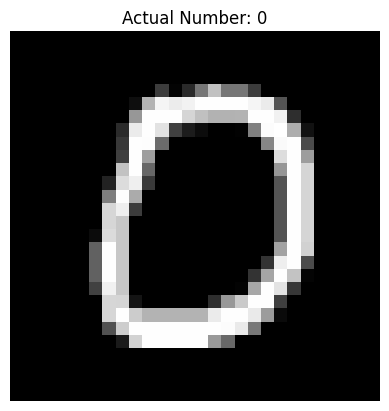

--------------------------------
Image Index     : 10
Actual Number   : 0
Predicted Number: 0
--------------------------------


In [8]:
#This is a CNN-based image classification model using PyTorch to recognize handwritten digits from the MNIST dataset. The model takes a 28×28 grayscale image as input and predicts one of 10 classes, from 0 to 9

#The model has two convolutional layers for extracting spatial features such as edges and shapes. Each convolutional layer is followed by ReLU activation and max pooling to introduce non-linearity and reduce the spatial dimensions. After feature extraction, I flatten the feature maps and pass them through fully connected layers, which finally produce 10 output values corresponding to the ten digits

# Archietecture
'''
    28 × 28 grayscale image
        ↓
    Conv2D: 1 → 8
        ↓
      ReLU
        ↓
      MaxPool
        ↓
    Conv2D: 8 → 16
        ↓
      ReLU
        ↓
      MaxPool
        ↓
    16 × 7 × 7
        ↓
  Flatten → 784
        ↓
  Linear: 784 → 64
        ↓
      ReLU
        ↓
  Linear: 64 → 10
        ↓
  Prediction: 0–9

'''

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Device
# --------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


# --------------------------------------------------
# 2. Transform
# --------------------------------------------------

transform = transforms.ToTensor()


# --------------------------------------------------
# 3. Load MNIST Dataset
# --------------------------------------------------

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


# --------------------------------------------------
# 4. DataLoader
# --------------------------------------------------

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)


# --------------------------------------------------
# 5. CNN Model
# --------------------------------------------------

class DigitModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=8,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                in_channels=8,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )


        self.classifier = nn.Sequential(

            nn.Linear(16 * 7 * 7, 64),

            nn.ReLU(),

            nn.Linear(64, 10)
        )


    def forward(self, x):

        x = self.features(x)

        # Flatten
        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x


# --------------------------------------------------
# 6. Create Model
# --------------------------------------------------

model = DigitModel().to(device)


# --------------------------------------------------
# 7. Loss and Optimizer
# --------------------------------------------------

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# --------------------------------------------------
# 8. Training
# --------------------------------------------------

epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)


        # Clear old gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = loss_fn(outputs, labels)


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        total_loss += loss.item()


    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {total_loss:.4f}"
    )


# --------------------------------------------------
# 9. Test Accuracy
# --------------------------------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)


accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")


# --------------------------------------------------
# 10. Pick One Image
# --------------------------------------------------

index = 10

image, true_label = test_data[index]


# --------------------------------------------------
# 11. Display Image
# --------------------------------------------------

plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Actual Number: {true_label}")

plt.axis("off")

plt.show()


# --------------------------------------------------
# 12. Predict the Number
# --------------------------------------------------

# Add batch dimension
image_input = image.unsqueeze(0).to(device)


with torch.no_grad():

    output = model(image_input)

    predicted_label = output.argmax(dim=1).item()


# --------------------------------------------------
# 13. Print Result
# --------------------------------------------------

print("--------------------------------")
print("Image Index     :", index)
print("Actual Number   :", true_label)
print("Predicted Number:", predicted_label)
print("--------------------------------")